# Seaborn 02 - Seaborn Advanced

> **MLCourse · Data Science Foundations · 04_seaborn**

Foundations down; time to operate like a pro. This notebook covers seaborn's
statistical heavyweights - regression plots, matrix heatmaps, hierarchical
clustering, and the joint/pair grid family - then goes deep on the
`FacetGrid` engine for fully custom multi-panel figures. We finish with
theme fine-tuning, seamless matplotlib interop, saving figures for reports,
and performance etiquette for large datasets.

Notebook 01 introduced the two-level API (axes-level vs figure-level); we
use that vocabulary constantly here.

### What you'll learn

- **Regression plots**: `regplot`, polynomial/logistic/robust/logx fits, CI
  bands, faceted `lmplot`, and residual diagnostics with `residplot`.
- **Matrix plots**: publication-grade correlation heatmaps with masks and
  annotations, plus one-line hierarchical clustering via `clustermap`.
- The **JointGrid family**: `jointplot` with scatter/kde/reg/hex/resid kinds.
- **pairplot / PairGrid**: scatterplot matrices, custom per-triangle plots.
- A **FacetGrid masterclass**: `map_dataframe` with custom functions,
  reference lines, titles, legends, and axis-sharing control.
- Theme fine-tuning: styles, contexts, despining, `rc` overrides.
- **Matplotlib interop**: annotations, second layers, resizing figure-level
  output post hoc, moving legends.
- Saving figures (`savefig`, dpi, SVG) and large-data etiquette.

### 1. Setup


### Same Jupyter-safe magic pattern as notebook 01: this file stays pure Python


In [ ]:
# while still enabling inline rendering inside notebooks.
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
except NameError:
    pass

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme()  # consistent look across every plot in this notebook


def load_dataset(name):
    """Load a built-in seaborn dataset with a friendly offline hint."""
    try:
        return sns.load_dataset(name)
    except Exception as exc:
        print(f"[offline hint] Could not load '{name}': {exc}")
        print("  Check your connection or fetch the CSV from")
        print("  https://github.com/mwaskom/seaborn-data and use pd.read_csv.")
        return None


tips = load_dataset("tips")
penguins = load_dataset("penguins")
mpg = load_dataset("mpg")
print("loaded:", {k: v.shape for k, v in
                  [("tips", tips), ("penguins", penguins), ("mpg", mpg)]})

tips.head()


### 2. Regression plots: fitting trends with uncertainty

`regplot` is axes-level and draws three things at once: the scatter, an
ordinary-least-squares line, and a shaded **95% confidence band** around it
(bootstrapped resamples of the data). The fit family is selectable:

- `order=2` - polynomial (quadratic) fit for curved relationships.
- `logistic=True` - S-curve fit for binary outcomes (pass/fail, buy/bounce).
- `robust=True` - downweights outliers (slower; worth knowing it exists).
- `logx=True` - fits y ~ log(x): straightens power-law-ish skewed data.
- `ci=None` - skip the band; dramatically faster on large data.

Style hooks: `scatter_kws=` and `line_kws=` pass dicts straight through to
matplotlib.

### Linear vs quadratic on the same data: total_bill vs tip bends slightly.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(data=tips, x="total_bill", y="tip", ax=axes[0],
            scatter_kws={"alpha": 0.45}, line_kws={"color": "crimson"})
axes[0].set_title("order=1 (default linear)")
sns.regplot(data=tips, x="total_bill", y="tip", order=2, ax=axes[1],
            scatter_kws={"alpha": 0.45}, line_kws={"color": "crimson"})
axes[1].set_title("order=2 captures the curvature")
plt.tight_layout()
plt.show()


### Logistic fit needs the optional `statsmodels` dependency; to keep this course


In [ ]:
# dependency-light we DEMO the S-curve idea with a low-order polynomial instead,
# and note that `logistic=True` becomes available after `pip install statsmodels`.
log_rng = np.random.default_rng(42)
study_hours = np.sort(log_rng.uniform(0, 10, 220))
prob_pass = 1 / (1 + np.exp(-(study_hours - 5)))          # true sigmoid
passed = log_rng.binomial(1, prob_pass)
exam = pd.DataFrame({"hours": study_hours, "passed": passed})

ax = sns.regplot(data=exam, x="hours", y="passed", order=3,
                 y_jitter=0.03, scatter_kws={"alpha": 0.35},
                 line_kws={"color": "darkgreen"})
ax.set_title("Binary outcome + order=3 bend (install statsmodels for logistic=True)")
plt.show()
# robust=True exists too - same call with robust=True downweights outliers,
# at a noticeable compute cost. Try it when a few extreme points drag the line.


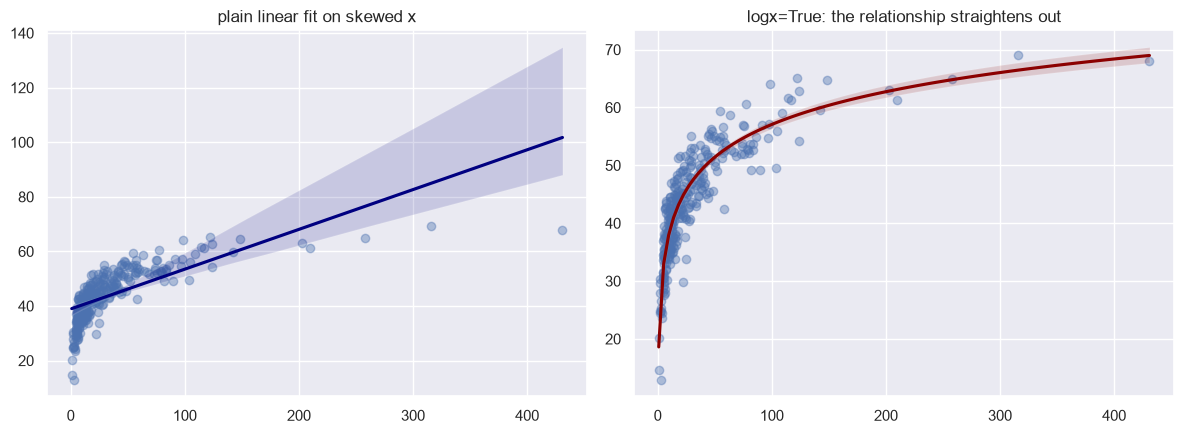

In [4]:
# logx demo on heavily right-skewed data: linear fit misses, logx nails it.
skew_rng = np.random.default_rng(0)
x_skew = skew_rng.lognormal(mean=3.0, sigma=1.0, size=300)      # long tail
y_skew = 20 + 8 * np.log(x_skew) + skew_rng.normal(0, 4, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(x=x_skew, y=y_skew, ax=axes[0],
            scatter_kws={"alpha": 0.4}, line_kws={"color": "navy"})
axes[0].set_title("plain linear fit on skewed x")
sns.regplot(x=x_skew, y=y_skew, logx=True, ax=axes[1],
            scatter_kws={"alpha": 0.4}, line_kws={"color": "darkred"})
axes[1].set_title("logx=True: the relationship straightens out")
plt.tight_layout()
plt.show()

> 💡 **Pro tip:** during exploration on big datasets pass `ci=None` - the
bootstrap behind the band is by far the most expensive part of regplot.

### 3. lmplot: faceted regression

`lmplot` is the figure-level wrapper over `regplot`: add `hue=`/`col=`/
`row=` and seaborn fits *and draws a separate regression per facet* -
perfect for asking "does the trend differ across groups?"

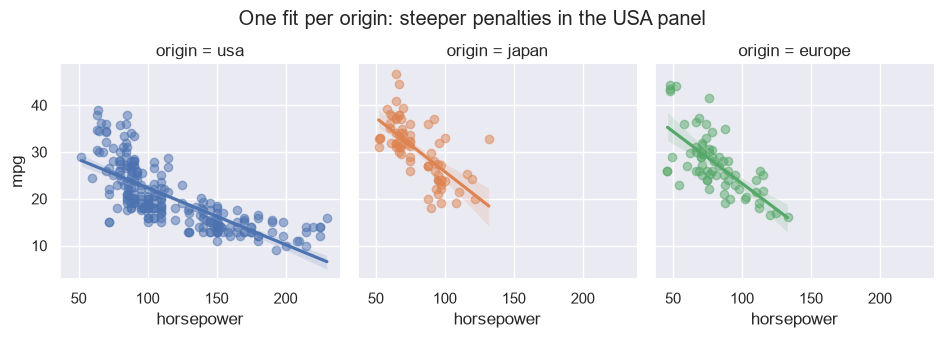

In [5]:
g = sns.lmplot(
    data=mpg, x="horsepower", y="mpg",
    col="origin", hue="origin",
    height=3.2, scatter_kws={"alpha": 0.5},
)
g.set_axis_labels("horsepower", "mpg")
g.figure.suptitle("One fit per origin: steeper penalties in the USA panel", y=1.05)
plt.show()

> ⚠️ **Common pitfall:** tiny facets produce wild, over-confident lines.
Check group sizes (`df["origin"].value_counts()`) before trusting a slope.

### 4. residplot: interrogating the fit

A residual is `y_actual - y_predicted`. If your model captured everything
systematic, residuals are structureless noise centered on zero - a flat,
even band. Any visible pattern means signal was left behind:

- Curvature → the relationship isn't linear (raise `order`).
- Funnel shape → variance grows with the mean (transform y, e.g. log).
- Waves → seasonality or missing predictors.

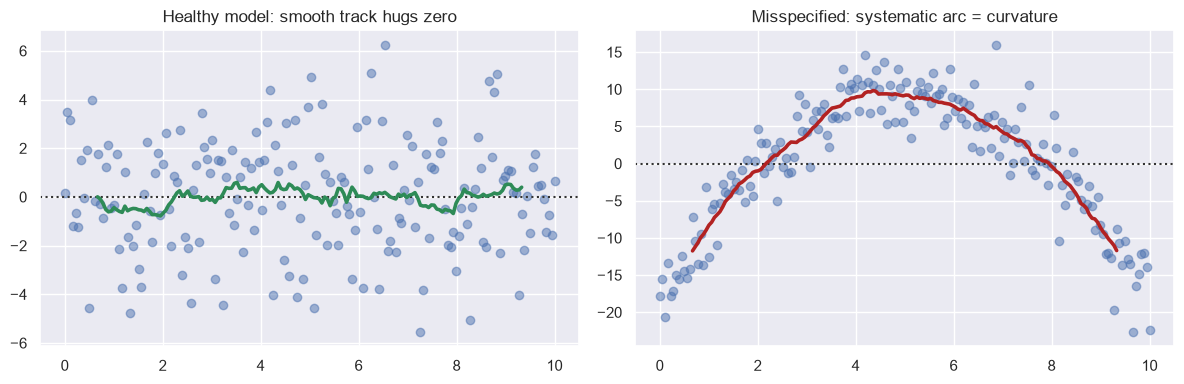

In [6]:
lin_rng = np.random.default_rng(11)
n_pts = 180
x_lin = np.linspace(0, 10, n_pts)

# Case 1: correctly specified linear model -> boring, flat residuals.
y_good = 3 + 2 * x_lin + lin_rng.normal(0, 2.5, n_pts)

# Case 2: quadratic reality forced through a linear model -> leftover curve.
y_quad_true = 3 + 2 * x_lin - 1.1 * x_lin**2 + lin_rng.normal(0, 3, n_pts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# seaborn's lowess=True needs the optional `statsmodels` package; we draw the
# same diagnostic with a dependency-free rolling-mean smoother instead.
for ax, y_vals, color, title in [
    (axes[0], y_good,      "seagreen",  "Healthy model: smooth track hugs zero"),
    (axes[1], y_quad_true, "firebrick", "Misspecified: systematic arc = curvature"),
]:
    # residuals of the default LINEAR fit:
    fitted = np.polyval(np.polyfit(x_lin, y_vals, 1), x_lin)
    resid = y_vals - fitted
    sns.residplot(x=x_lin, y=y_vals,
                  scatter_kws={"alpha": 0.5}, ax=ax)          # dots only
    idx = np.argsort(x_lin)                                   # sort for the smoother
    smooth = pd.Series(resid[idx]).rolling(25, center=True).mean()
    ax.plot(np.asarray(x_lin)[idx], smooth, color=color, lw=2.6)
    ax.set_title(title)

plt.tight_layout()
plt.show()
# A flat colored track = healthy fit; the red arc IS the diagnosis: raise the
# polynomial order and re-check. (Install statsmodels to use built-in lowess.)

### 5. Matrix heatmaps + a full correlation workflow

`heatmap` renders any 2-D numeric table as colored cells. Key options:

- `annot=True, fmt=".2f"` prints values in cells; `annot_kws={"fontsize": 8}`
  styles the numbers.
- `linewidths=, linecolor=` separates cells visually.
- `cmap=` choose by semantics: sequential for magnitude (`mako`),
  **diverging centered on a meaningful midpoint** for signed values
  (`vlag`, `coolwarm`, `center=0`).
- `mask=` hides cells - correlation matrices are symmetric, so mask the
  upper triangle and let readers focus.
- `square=True` keeps cells square; `vmin/vmax` pin the color scale.

Below: the complete workflow on penguin measurements - compute correlations,
mask redundancy, annotate, then extract and interpret the strongest pairs.

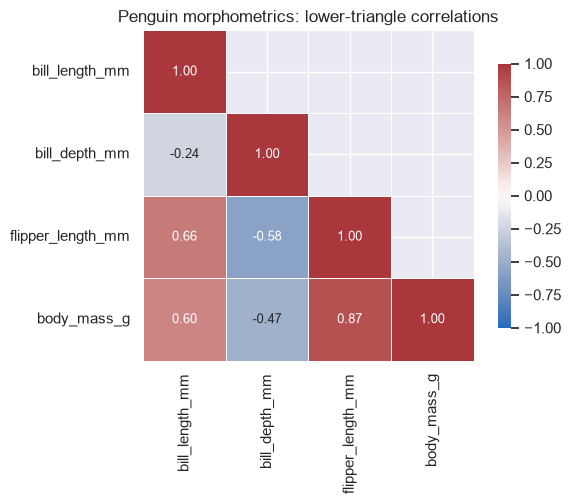

          level_0           level_1         r
flipper_length_mm       body_mass_g  0.871202
   bill_length_mm flipper_length_mm  0.656181
   bill_length_mm       body_mass_g  0.595110
    bill_depth_mm flipper_length_mm -0.583851


In [7]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr = penguins[num_cols].corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide above-diagonal

fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="vlag", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    square=True, annot_kws={"fontsize": 9}, cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Penguin morphometrics: lower-triangle correlations")
plt.tight_layout()
plt.show()

# Extract the strongest absolute pairs programmatically.
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # keep each pair once
        .stack()
        .rename("r")
        .reset_index()
        .sort_values("r", key=np.abs, ascending=False)
)
print(pairs.head(4).to_string(index=False))

Reading the heatmap: flipper length and body mass move together strongly
(~0.87) - bigger penguins have longer flippers. Bill depth correlates
*negatively* with bill length (~-0.24 overall) largely because the large
Gentoo species has long but shallow bills - a first taste of Simpson's
paradox worth checking per-species.

> ⚠️ **Common pitfall:** Pearson's r only measures *linear* association.
Plot the scatter before believing r ≈ 0 means "no relationship"
(`method="kendall"` or `"spearman"` handles monotonic-but-nonlinear cases).

> 💡 **Pro tip:** diverging palettes without `center=` are lying to you -
always anchor them at the value that means "nothing happening" (usually 0).

### 6. clustermap: clustered heatmap one-liner

`clustermap` wraps `heatmap` and adds **hierarchical clustering**: rows and
columns are reordered so similar ones sit together, and dendrograms show the
merge tree. It is unsupervised - no species labels needed - yet structure
pops out. We sneak `row_colors=` in to color rows by true species and see
how well clustering recovers them.

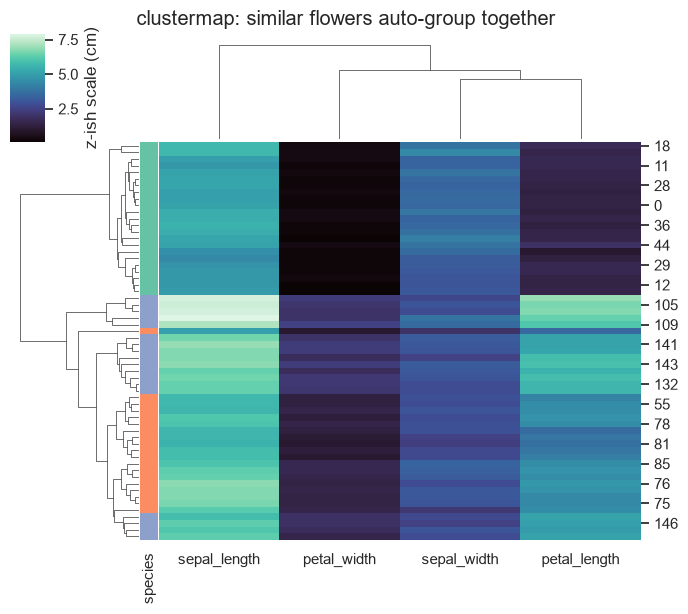

In [8]:
iris = load_dataset("iris")
if iris is not None:
    iris_sample = iris.sample(60, random_state=42)
    species_palette = dict(zip(["setosa", "versicolor", "virginica"],
                               sns.color_palette("Set2", 3)))
    cg = sns.clustermap(
        iris_sample.iloc[:, :4],                 # the four measurements only
        cmap="mako", figsize=(7, 6),
        row_colors=iris_sample["species"].map(species_palette),
        cbar_kws={"label": "z-ish scale (cm)"},
    )
    cg.figure.suptitle("clustermap: similar flowers auto-group together", y=1.02)
    plt.show()
else:
    print("Skipping clustermap demo - iris unavailable.")

Each dendrogram arm joins the two most similar items/clusters first
(average linkage by default). Setosa separates cleanly; versicolor and
virginica overlap - exactly what PCA-style analyses report too.

> 💡 **Pro tip:** features on wildly different scales? Standardize first
(`standard_scale=1` per column, or `z_score=1`) so big units don't dominate
the distance metric.

### 7. jointplot: bivariate + marginals

A scatter alone hides *why* points cluster; marginal distributions reveal
whether clusters differ along one axis, both, or neither. `jointplot`
(figure-level) pairs a central plot with histograms/KDEs on the margins.
Switch the centerpiece with `kind=`:

| kind | central plot | best for |
|---|---|---|
| `"scatter"` (default) | points | moderate n, spotting groups |
| `"kde"` | 2-D density contours | smooth overview, many points |
| `"hex"` | hexagonal binning counts | very large n |
| `"reg"` | scatter + linear fit + CI | quick trend check |
| `"resid"` | residuals of linear fit | diagnosing the trend |

`marginal_ticks=True` shows tick labels on the margin axes.

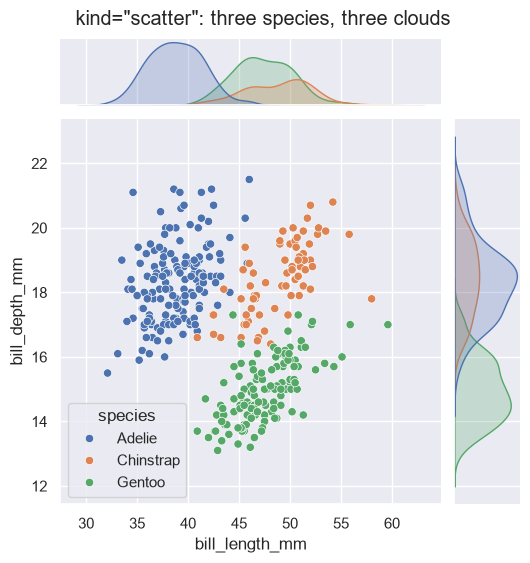

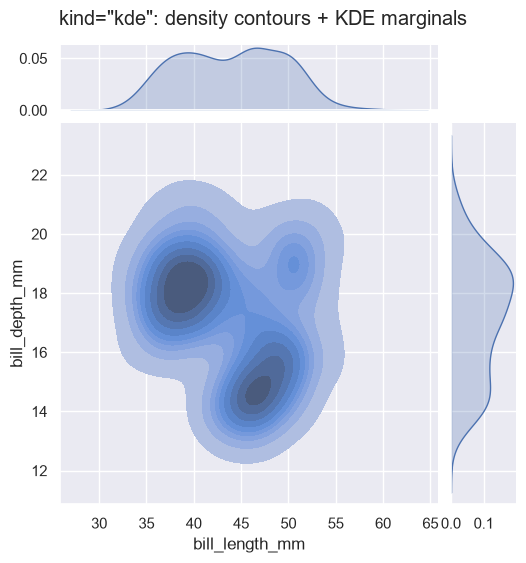

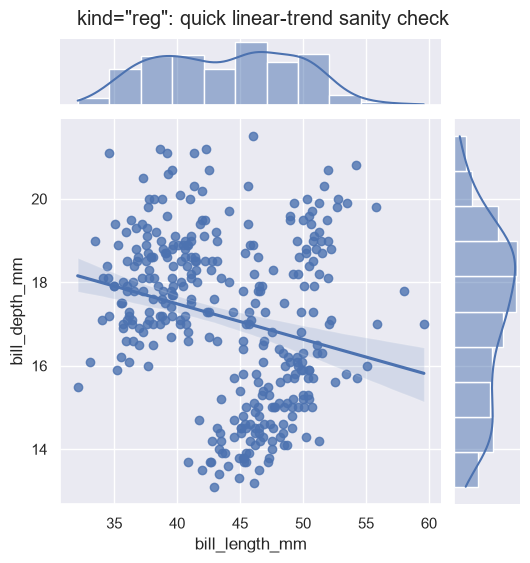

In [9]:
bill = penguins.dropna(subset=["bill_length_mm", "bill_depth_mm"])

j1 = sns.jointplot(data=bill, x="bill_length_mm", y="bill_depth_mm",
                   hue="species", height=5.5)
j1.figure.suptitle('kind="scatter": three species, three clouds', y=1.02)
plt.show()

j2 = sns.jointplot(data=bill, x="bill_length_mm", y="bill_depth_mm",
                   kind="kde", fill=True, height=5.5, marginal_ticks=True)
j2.figure.suptitle('kind="kde": density contours + KDE marginals', y=1.02)
plt.show()

j3 = sns.jointplot(data=bill, x="bill_length_mm", y="bill_depth_mm",
                   kind="reg", height=5.5)
j3.figure.suptitle('kind="reg": quick linear-trend sanity check', y=1.02)
plt.show()
plt.close("all")  # exploration produced several windows - tidy up

> ⚠️ **Common pitfall:** with tens of thousands of points, plain scatters
become solid ink. That is the cue for `kind="hex"` (next exercise) or
`kind="kde"`.

### 8. pairplot: the scatterplot matrix

`pairplot` renders every pairwise scatter plus per-variable diagonals -
the fastest way to eyeball separability of groups across all dimensions.
Key options:

- `hue=` colors everything by class (legend included).
- `diag_kind="kde"` smooths diagonals (vs default histogram).
- `corner=True` drops the redundant mirrored upper triangle - essential once
  you exceed ~5 variables.
- `vars=[...]` selects a subset of columns.
- `plot_kws={"alpha": ..., "s": ...}` fights overplotting.

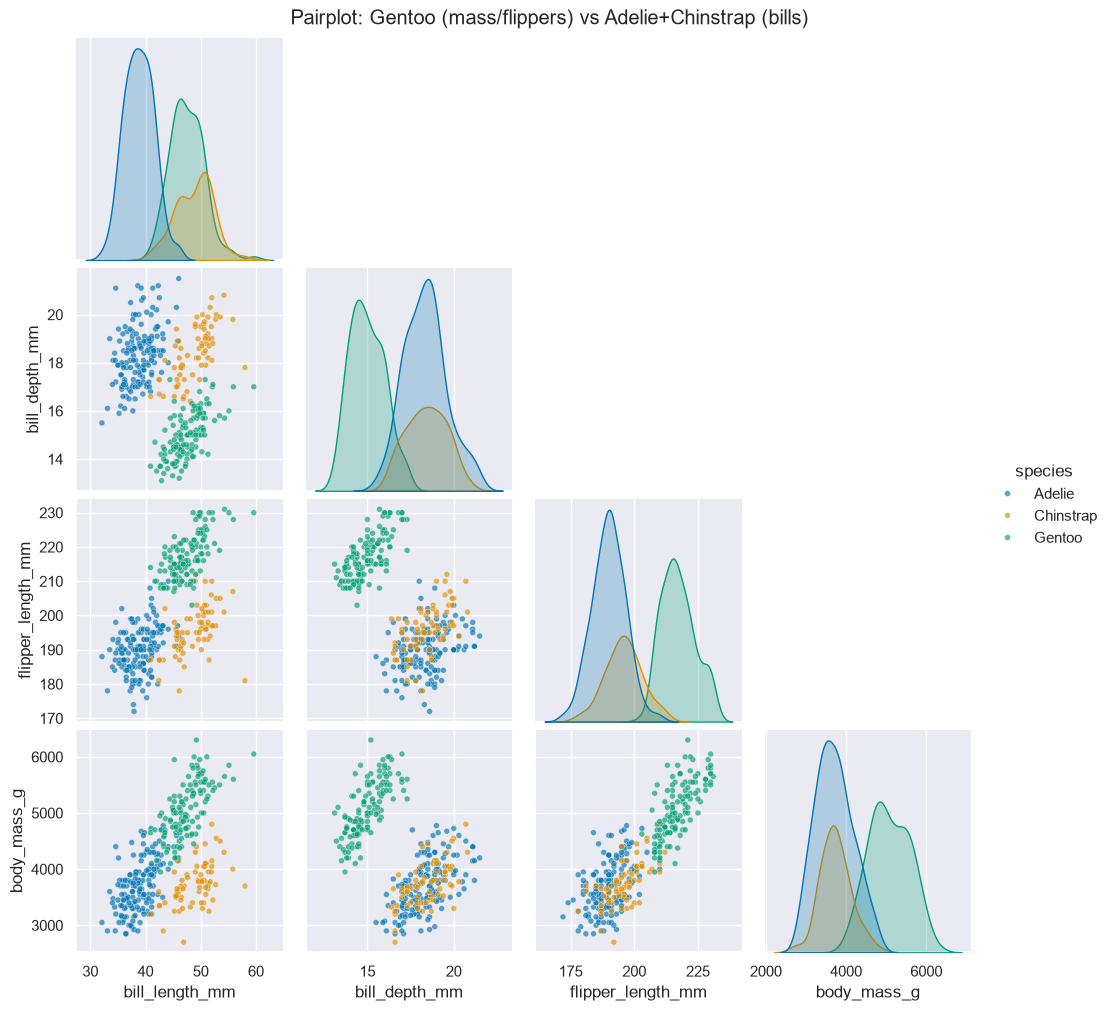

In [10]:
peng_clean = penguins.dropna(subset=num_cols + ["species"])
pp = sns.pairplot(
    peng_clean,
    vars=num_cols,
    hue="species",
    diag_kind="kde",          # smooth diagonals
    corner=True,              # half the panels, same information
    palette="colorblind",
    plot_kws={"s": 18, "alpha": 0.65},
)
pp.figure.suptitle("Pairplot: Gentoo (mass/flippers) vs Adelie+Chinstrap (bills)", y=1.01)
plt.show()

> 💡 **Pro tip:** pairplots are O(k²) panels - for k > 8 variables sample
rows AND select `vars=` deliberately, or the figure becomes wallpaper.

### 9. FacetGrid masterclass: custom multi-panel figures

When `catplot`-style presets aren't enough, drive `FacetGrid` directly:

```python
g = sns.FacetGrid(df, row=..., col=..., hue=..., margin_titles=...,
                  height=..., aspect=..., sharex=True, sharey=True)
g.map_dataframe(plotting_function, ...)
```

`map_dataframe(func)` calls `func(data_subset, **kwargs)` once per facet;
inside a custom function you draw on the current axes (`plt.gca()`).
Handy methods: `g.refline(...)` global reference lines, `g.set_titles(...)`,
`g.add_legend()`, `g.despine()`, and `sharex/sharey=False` to free axes.

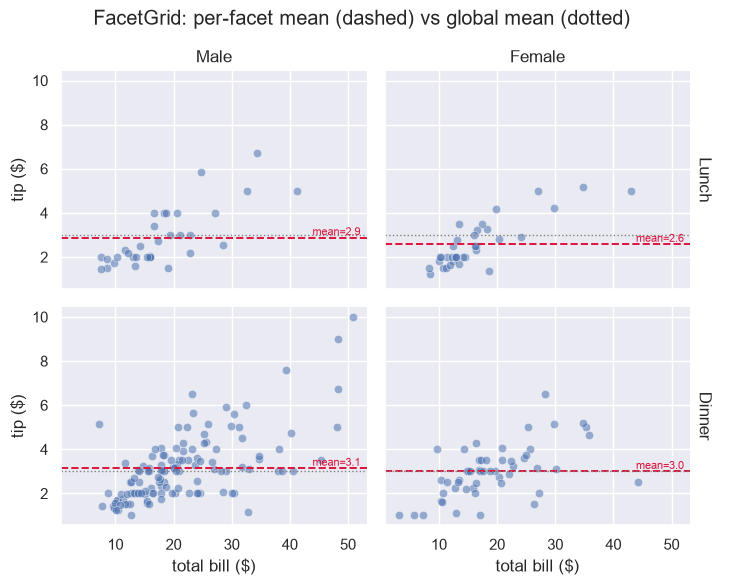

In [11]:
def mark_group_mean(data, y, **kws):
    """Custom per-facet overlay: dashed crimson line at the facet's mean."""
    ax = plt.gca()
    mean_val = data[y].mean()
    ax.axhline(mean_val, ls="--", lw=1.4, color="crimson")
    ax.text(0.98, mean_val, f"mean={mean_val:.1f}",
            va="bottom", ha="right", fontsize=8, color="crimson",
            transform=ax.get_yaxis_transform())


g = sns.FacetGrid(tips, row="time", col="sex",
                  margin_titles=True, height=2.8, aspect=1.3)
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip", alpha=0.55)
g.map_dataframe(mark_group_mean, y="tip")
g.refline(y=tips["tip"].mean(), color="gray", ls=":", lw=1)   # GLOBAL mean
g.set_axis_labels("total bill ($)", "tip ($)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.add_legend()
g.figure.suptitle("FacetGrid: per-facet mean (dashed) vs global mean (dotted)", y=1.04)
plt.show()

### Free scales: col_wrap reflows facets into rows; sharey=False lets each day


In [ ]:
# use its own y-range (great for counts of very different magnitudes).
g2 = sns.FacetGrid(tips, col="day", col_wrap=2, height=2.6,
                   sharey=False)
g2.map_dataframe(sns.histplot, x="total_bill", bins=15)
g2.set_titles("{col_name}")
g2.figure.suptitle("sharey=False + col_wrap=2", y=1.03)
plt.show()


> ⚠️ **Common pitfall:** with `sharey=False` readers compare bar heights
across facets at their peril. Free scales only when the caption warns about
it.

### 10. PairGrid: bespoke scatterplot matrices

`PairGrid` is the engine under `pairplot`; using it directly lets you assign
a *different* plot type to each triangle:

- `g.map_diag(fn)` - diagonal (one variable's distribution).
- `g.map_upper(fn)` / `g.map_lower(fn)` - off-diagonal bivariate views.

Recipe below: KDE-filled diagonals, raw scatters up top, per-hue regression
lines underneath.

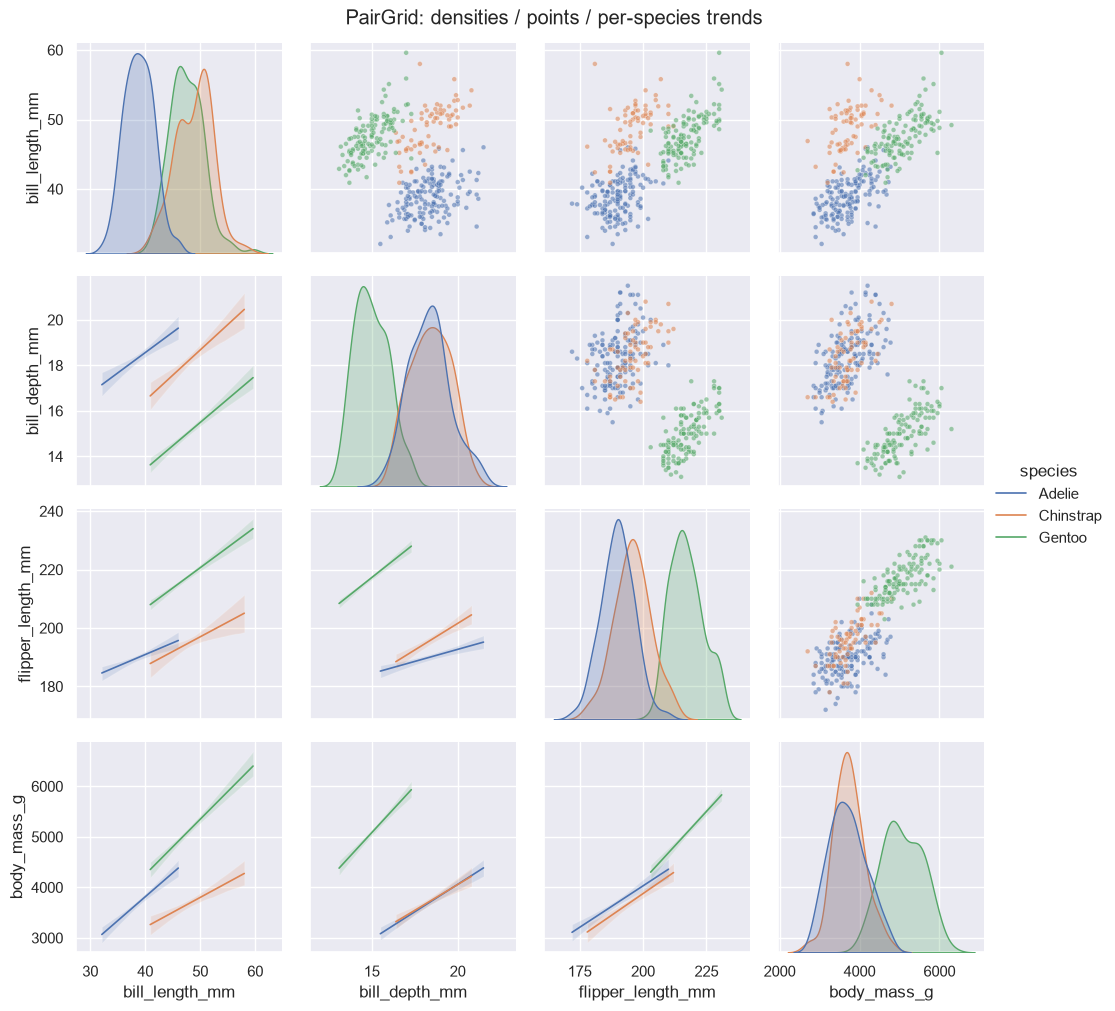

In [13]:
pg = sns.PairGrid(peng_clean, vars=num_cols, hue="species",
                  diag_sharey=False, corner=False)
pg.map_diag(sns.kdeplot, fill=True, common_norm=False)
pg.map_upper(sns.scatterplot, s=12, alpha=0.55)
pg.map_lower(sns.regplot, scatter=False, line_kws={"lw": 1.2})
pg.add_legend()
pg.figure.suptitle("PairGrid: densities / points / per-species trends", y=1.01)
plt.show()

> 💡 **Pro tip:** `corner=True` works here too, and `map_lower` with
`scatter=False` keeps dense matrices legible - lines carry the trend, ink
stays low.

### 11. Fine-tuning themes: styles, contexts, despining

Quick reference (details in notebook 01):

- Styles: `darkgrid`, `whitegrid`, `dark`, `white`, `ticks`.
- Contexts scale text/lines: `paper`, `notebook`, `talk`, `poster`.
- `sns.despine(ax=ax, offset=10, trim=True)` pulls spines away from the
  data and trims them to the data range - instant polish.
- Persistent one-off settings go through `rc=`:
  `sns.set_theme(style="white", rc={"axes.spines.top": False})`.

### Mini style gallery on real data.


In [ ]:
for style_name in ["whitegrid", "ticks", "dark"]:
    with sns.axes_style(style_name):
        fig, ax = plt.subplots(figsize=(4.2, 2.8))
        sns.boxplot(data=tips[tips["day"] == "Sat"], x="smoker", y="tip", ax=ax)
        ax.set_title(f'style="{style_name}"')
        plt.show()


### Context scaling: same chart prepared for a paper vs a conference talk.


In [ ]:
for ctx in ["paper", "talk"]:
    with sns.plotting_context(ctx):
        fig, ax = plt.subplots(figsize=(4.6, 3.2))
        sns.pointplot(data=tips, x="day", y="tip", hue="smoker", ax=ax)
        ax.set_title(f'context="{ctx}"')
        plt.show()


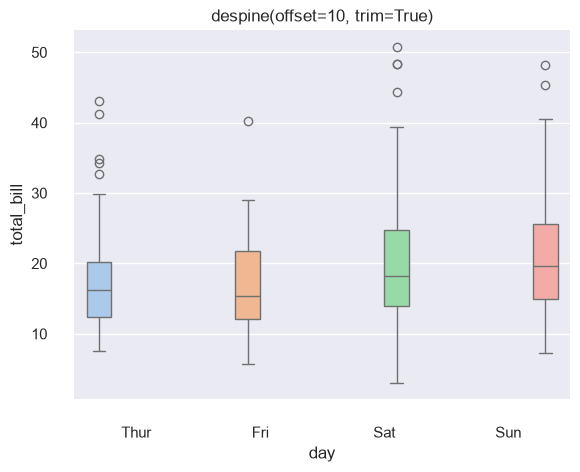

In [16]:
ax = sns.boxplot(data=tips, x="day", y="total_bill", hue="day", legend=False, palette="pastel")
sns.despine(ax=ax, offset=10, trim=True)   # float the spines off the data
ax.set_title("despine(offset=10, trim=True)")
plt.show()

### 12. Matplotlib interop: seaborn inside your figures

Because seaborn outputs real matplotlib artists, you can:

1. Capture the returned `Axes` and annotate/add layers afterwards.
2. Resize figure-level output *after* creation via `g.figure.set_size_inches`.
3. Title properly: `ax.set_title` for one panel; `g.figure.suptitle` for a
   FacetGrid's whole window.
4. Relocate legends anywhere with `sns.move_legend(ax_or_grid, loc)`.
5. Mix raw matplotlib calls onto seaborn axes (or vice versa).

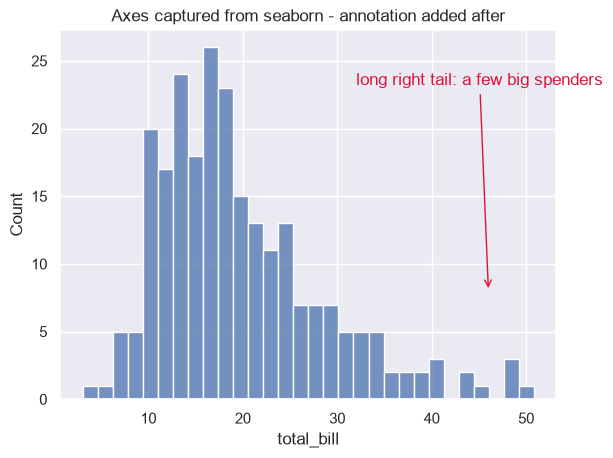

In [17]:
# 1) Grab the Axes, then annotate like any matplotlib artist.
ax = sns.histplot(data=tips, x="total_bill", bins=30)
peak_y = ax.get_ylim()[1] * 0.85
ax.annotate(
    "long right tail: a few big spenders",
    xy=(46, 8), xytext=(32, peak_y),
    arrowprops=dict(arrowstyle="->", color="crimson"),
    color="crimson",
)
ax.set_title("Axes captured from seaborn - annotation added after")
plt.show()

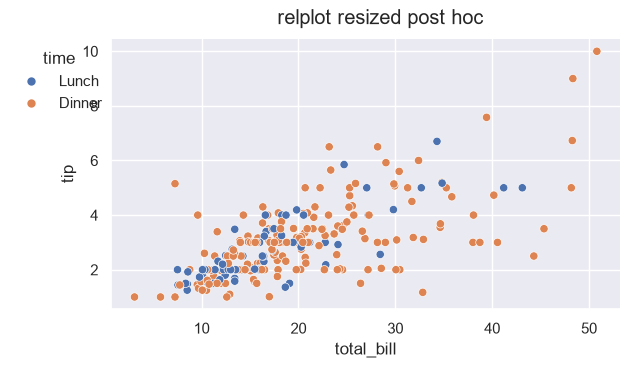

In [18]:
# 2) + 4) Figure-level objects: resize after the fact and move the legend.
g = sns.relplot(data=tips, x="total_bill", y="tip", hue="time",
                height=3.4, aspect=1.0)
g.figure.set_size_inches(9, 3.6)          # reshape AFTER plotting
g.figure.suptitle("relplot resized post hoc", y=1.03)
sns.move_legend(g, "upper left", bbox_to_anchor=(0.08, 0.95), frameon=False)
plt.show()

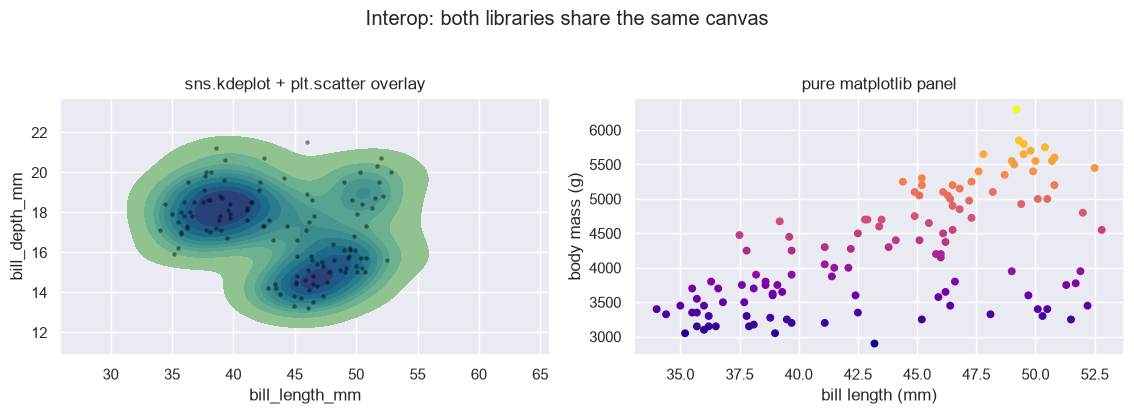

In [19]:
# 5) Mixing engines: seaborn KDE + raw matplotlib scatter on shared axes,
#    next to a pure-matplotlib panel - one Figure, two libraries, zero friction.
sub = bill.sample(120, random_state=1)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
sns.kdeplot(data=bill, x="bill_length_mm", y="bill_depth_mm",
            fill=True, cmap="crest", ax=axes[0])
axes[0].scatter(sub["bill_length_mm"], sub["bill_depth_mm"],
                s=10, c="black", alpha=0.45, linewidths=0)   # mpl layer on sns ax
axes[0].set_title("sns.kdeplot + plt.scatter overlay")
axes[1].scatter(sub["bill_length_mm"], sub["body_mass_g"], c=sub["body_mass_g"],
                cmap="plasma", s=22)
axes[1].set_xlabel("bill length (mm)")
axes[1].set_ylabel("body mass (g)")
axes[1].set_title("pure matplotlib panel")
fig.suptitle("Interop: both libraries share the same canvas", y=1.03)
plt.tight_layout()
plt.show()

> ⚠️ **Common pitfall:** on figure-level grids there is no single `ax`;
reach individual panels via `g.axes_dict` (keyed by facet variable) or the
numpy array `g.axes`. Calling `ax.set_title` blindly will not do what you
want.

### 13. Saving figures for reports and slides

Two paths, matching the two levels:

- Axes-level: keep the `Figure` (`fig, _ = plt.subplots(...)`) then
  `fig.savefig(name, dpi=..., bbox_inches="tight")`.
- Figure-level: `g.savefig(name)` saves the whole facet window.

Formats: `png` + `dpi=150` for screens/slides, `dpi=300` for print, and
`svg`/`pdf` vector formats that stay crisp at any zoom in reports.

### Axes-level path: build on a known Figure, then save it.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=tips, x="day", y="total_bill", ax=ax)
ax.set_title("Demo figure destined for disk")
fig.savefig("mlcourse_demo_box.png", dpi=200, bbox_inches="tight")

# Figure-level path: FacetGrid objects carry their own savefig.
g_save = sns.lmplot(data=mpg, x="weight", y="mpg", col="origin",
                    height=3, scatter_kws={"alpha": 0.5})
g_save.figure.suptitle("Vector export demo", y=1.04)
g_save.savefig("mlcourse_demo_lm.svg")     # vector: infinitely scalable
print("Saved: mlcourse_demo_box.png, mlcourse_demo_lm.svg")


> 💡 **Pro tip:** `bbox_inches="tight"` crops stray whitespace automatically;
pair it with `dpi=300` for camera-ready submissions.

### 14. Performance and etiquette on large data

Rules that keep exploration fast and laptops cool:

1. **Sample first.** Diamonds has ~54k rows; `.sample(5000, random_state=42)`
   gives identical-looking charts in a fraction of the time (and a
   reproducible subset!).
2. **Skip uncertainty while exploring**: `ci=None` / `errorbar=None` removes
   the expensive bootstrap until the final render.
3. **Know the cost curves**: KDE ≈ O(n·grid²) per dimension; swarm ≈
   quadratic - avoid swarms past a few thousand points per category.
4. **Close stale figures** (`plt.close("all")`) during loops to cap memory.

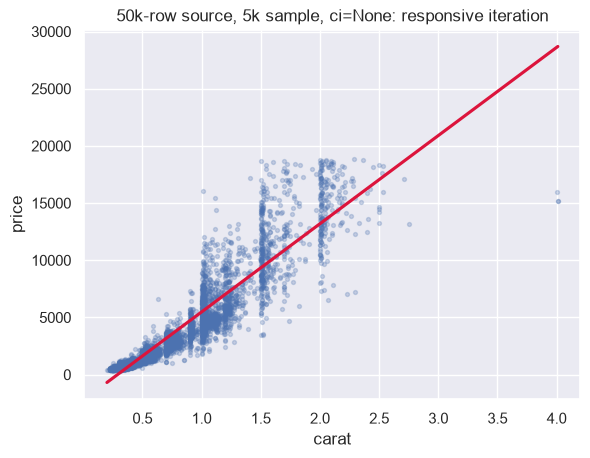

In [21]:
diamonds = load_dataset("diamonds")
if diamonds is not None:
    dia_small = diamonds.sample(5000, random_state=42)
    ax = sns.regplot(
        data=dia_small, x="carat", y="price",
        ci=None,                       # exploration mode: no bootstrap band
        scatter_kws={"s": 8, "alpha": 0.25},
        line_kws={"color": "crimson"},
    )
    ax.set_title("50k-row source, 5k sample, ci=None: responsive iteration")
else:
    print("Skipping performance demo - diamonds unavailable.")
plt.show()

### Summary & key takeaways

- `regplot` bundles scatter + fit + CI; bend it with `order=`, `logistic=`,
  `logx=`, speed it up with `ci=None`; `lmplot` adds per-facet fits;
  `residplot` is your misspecification detector (flat band = done).
- Heatmaps need deliberate `cmap` + `center` choices; mask correlation
  triangles, annotate cells, and read top pairs programmatically.
- `clustermap` turns a matrix into an unsupervised similarity map with
  dendrograms; standardize features with mixed units first.
- `jointplot` (scatter/kde/hex/reg/resid) answers bivariate questions with
  built-in marginal context; `pairplot`/`PairGrid` scale that to k² panels
  (`corner=True` beyond five variables).
- `FacetGrid.map_dataframe` accepts your own functions - per-facet means,
  percentile bands, anything - plus `refline`, templated titles, legends.
- Seaborn and matplotlib interleave freely: capture axes, annotate, resize,
  `move_legend`, mix layers.
- Save with `savefig(dpi=...)` for raster and SVG/PDF for vector reports.
- Large data: sample reproducibly, drop CIs while exploring, respect
  algorithmic costs.

Ready to drive solo? Head to **03_seaborn_exercises** for twelve graded
challenges, with fully worked solutions in **04_seaborn_solutions**.